# Observations from OUTCOME_MORTALITY.csv

This file is an output of Program 1 in the CMS Overall Star Rating SAS Pack. 
In this file, each row represents individual hospital's mortality group score data.

Columns: `provider_ID`, `total_cnt`, `measure_wt`, `score_before_std`, `Mean`, `StdDev`, `grp_score`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

## 1. Load data

In [2]:
# Update path as needed
df = pd.read_csv("OUTCOME_MORTALITY.csv")
df.shape

(4566, 21)

In [3]:
df.head()

,PROVIDER_ID,std_MORT_30_AMI,std_MORT_30_CABG,std_MORT_30_COPD,std_MORT_30_HF,std_MORT_30_PN,std_MORT_30_STK,std_PSI_4_SURG_COMP,C1,C2,C3,C4,C5,C6,C7,total_cnt,measure_wt,score_before_std,Mean,StdDev,grp_score
0,010001,1.405923,-1.045370,1.011496,0.650904,-0.315375,0.023766,-0.732077,1,1,1,1,1,1,1,7,0.142857,0.142753,-0.073484,0.730255,0.296110
1,010005,-1.492798,NaN,0.150309,-0.366857,-1.766289,-0.083025,-0.576021,1,0,1,1,1,1,1,6,0.166667,-0.689113,-0.073484,0.730255,-0.843034
2,010006,-3.138018,-2.730472,-0.512142,-0.135547,-0.626285,-0.243212,-1.004318,1,1,1,1,1,1,1,7,0.142857,-1.198571,-0.073484,0.730255,-1.540677
3,010007,NaN,NaN,-2.698232,-1.014523,-3.804479,NaN,NaN,0,0,1,1,1,0,0,3,0.333333,-2.505745,-0.073484,0.730255,-3.330700
4,010008,NaN,NaN,NaN,NaN,-0.419012,NaN,NaN,0,0,0,0,1,0,0,1,1.000000,-0.419012,-0.073484,0.730255,-0.473161


In [4]:
df.dtypes

PROVIDER_ID                str
std_MORT_30_AMI        float64
std_MORT_30_CABG       float64
std_MORT_30_COPD       float64
std_MORT_30_HF         float64
std_MORT_30_PN         float64
std_MORT_30_STK        float64
std_PSI_4_SURG_COMP    float64
C1                       int64
C2                       int64
C3                       int64
C4                       int64
C5                       int64
C6                       int64
C7                       int64
total_cnt                int64
measure_wt             float64
score_before_std       float64
Mean                   float64
StdDev                 float64
grp_score              float64
dtype: object

## 2. Missing values

In [5]:
df.isna().sum()

PROVIDER_ID               0
std_MORT_30_AMI        2564
std_MORT_30_CABG       3677
std_MORT_30_COPD       1919
std_MORT_30_HF         1423
std_MORT_30_PN          937
std_MORT_30_STK        2353
std_PSI_4_SURG_COMP    2997
C1                        0
C2                        0
C3                        0
C4                        0
C5                        0
C6                        0
C7                        0
total_cnt                 0
measure_wt              884
score_before_std        884
Mean                      0
StdDev                    0
grp_score               884
dtype: int64

In [6]:
(df.isna().sum() / len(df) * 100).round(2)

PROVIDER_ID             0.00
std_MORT_30_AMI        56.15
std_MORT_30_CABG       80.53
std_MORT_30_COPD       42.03
std_MORT_30_HF         31.17
std_MORT_30_PN         20.52
std_MORT_30_STK        51.53
std_PSI_4_SURG_COMP    65.64
C1                      0.00
C2                      0.00
C3                      0.00
C4                      0.00
C5                      0.00
C6                      0.00
C7                      0.00
total_cnt               0.00
measure_wt             19.36
score_before_std       19.36
Mean                    0.00
StdDev                  0.00
grp_score              19.36
dtype: float64

Rows with `total_cnt` = 0 or missing will have missing `score_before_std` and `grp_score` (hospital reported no measures in this group).

In [7]:
df['total_cnt'].value_counts(dropna=False).sort_index()

total_cnt
0    884
1    503
2    432
3    452
4    398
5    456
6    590
7    851
Name: count, dtype: int64

## 3. Duplicates and ID check

In [15]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate provider_ID:", df['PROVIDER_ID'].duplicated().sum())
print("Unique providers:", df['PROVIDER_ID'].nunique())

Duplicate rows: 0
Duplicate provider_ID: 0
Unique providers: 4566


## 4. Summary statistics

In [16]:
df.describe()

,std_MORT_30_AMI,std_MORT_30_CABG,std_MORT_30_COPD,std_MORT_30_HF,std_MORT_30_PN,std_MORT_30_STK,std_PSI_4_SURG_COMP,C1,C2,C3,C4,C5,C6,C7,total_cnt,measure_wt,score_before_std,Mean,StdDev,grp_score
count,2.002000e+03,8.890000e+02,2.647000e+03,3.143000e+03,3.629000e+03,2.213000e+03,1.569000e+03,4566.000000,4566.000000,4566.000000,4566.000000,4566.000000,4566.000000,4566.000000,4566.000000,3682.000000,3682.000000,4566.000000,4.566000e+03,3.682000e+03
mean,-3.396582e-12,-1.271091e-11,5.213444e-12,-1.333121e-11,6.696059e-12,-1.943069e-12,-5.098654e-13,0.438458,0.194700,0.579720,0.688349,0.794788,0.484669,0.343627,3.524310,0.347711,-0.073484,-0.073484,7.302550e-01,3.530705e-13
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.496252,0.396013,0.493658,0.463219,0.403901,0.499820,0.474970,2.576021,0.282097,0.730255,0.000000,1.110345e-16,1.000000e+00
min,-3.921456e+00,-5.017396e+00,-5.811754e+00,-5.224352e+00,-4.633573e+00,-4.141088e+00,-3.454486e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.142857,-3.528114,-0.073484,7.302550e-01,-4.730717e+00
25%,-6.310160e-01,-5.639121e-01,-5.783875e-01,-6.444279e-01,-6.262851e-01,-5.635850e-01,-6.420447e-01,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.166667,-0.508719,-0.073484,7.302550e-01,-5.960051e-01
50%,7.407834e-02,1.582745e-01,8.406402e-02,4.950005e-02,3.008103e-02,7.716178e-02,2.333783e-02,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,0.200000,-0.039389,-0.073484,7.302550e-01,4.668896e-02
75%,7.008289e-01,7.600966e-01,6.802704e-01,6.509043e-01,6.864471e-01,6.645130e-01,6.629968e-01,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,0.500000,0.408870,-0.073484,7.302550e-01,6.605268e-01
max,3.834581e+00,2.084105e+00,2.667625e+00,3.195307e+00,3.242820e+00,3.067313e+00,3.989052e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000,1.000000,2.907761,-0.073484,7.302550e-01,4.082470e+00


## 5. Distributions

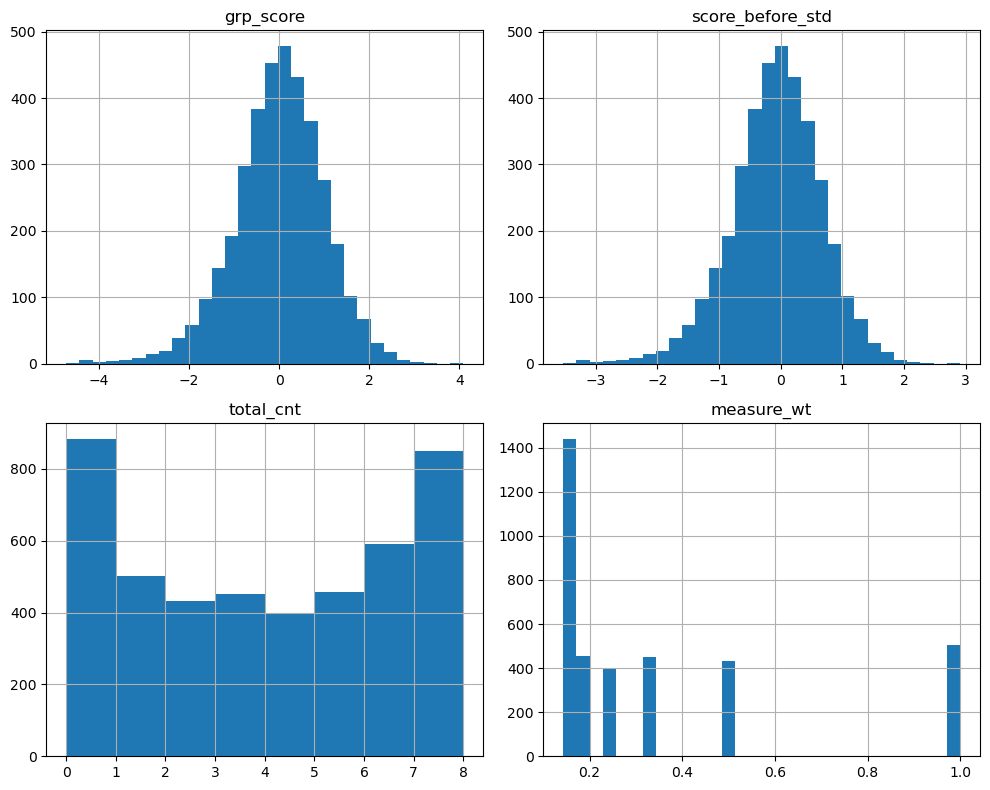

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
df['grp_score'].hist(ax=axes[0,0], bins=30)
axes[0,0].set_title('grp_score')
df['score_before_std'].hist(ax=axes[0,1], bins=30)
axes[0,1].set_title('score_before_std')
df['total_cnt'].hist(ax=axes[1,0], bins=range(0,9))
axes[1,0].set_title('total_cnt')
df['measure_wt'].hist(ax=axes[1,1], bins=30)
axes[1,1].set_title('measure_wt')
plt.tight_layout()
plt.show()

## 6. Checks against SAS logic

`measure_wt` should equal 1 / `total_cnt`. `Mean` and `StdDev` should be constant across all rows (they are the national mean/stddev used to standardize).

In [18]:
check = df.dropna(subset=['total_cnt', 'measure_wt'])
mismatch = check[~np.isclose(check['measure_wt'], 1/check['total_cnt'])]
print("Rows where measure_wt != 1/total_cnt:", len(mismatch))

Rows where measure_wt != 1/total_cnt: 0


In [19]:
print("Unique Mean values:", df['Mean'].nunique())
print("Unique StdDev values:", df['StdDev'].nunique())
print("Mean value:", df['Mean'].dropna().unique())
print("StdDev value:", df['StdDev'].dropna().unique())

Unique Mean values: 1
Unique StdDev values: 1
Mean value: [-0.073484]
StdDev value: [0.730255]


In [20]:
# grp_score should equal (score_before_std - Mean) / StdDev
check2 = df.dropna(subset=['score_before_std', 'Mean', 'StdDev', 'grp_score'])
expected = (check2['score_before_std'] - check2['Mean']) / check2['StdDev']
diff = (expected - check2['grp_score']).abs()
print("Max abs diff:", diff.max())
print("Rows off by > 0.001:", (diff > 0.001).sum())

Max abs diff: 1.6334212737945109e-06
Rows off by > 0.001: 0


## 7. Correlations

In [21]:
df[['total_cnt','measure_wt','score_before_std','grp_score']].corr()

,total_cnt,measure_wt,score_before_std,grp_score
total_cnt,1.000000,-0.865687,0.206675,0.206675
measure_wt,-0.865687,1.000000,-0.191750,-0.191750
score_before_std,0.206675,-0.191750,1.000000,1.000000
grp_score,0.206675,-0.191750,1.000000,1.000000


## 8. Notes

- Rows with no reported mortality measures have missing `score_before_std` and `grp_score`; which is expected here as per documentation.
- `Mean`/`StdDev` are constants (national mean/stddev used for standardization), and not per-hospital values.